# 신경망 기초 - 로지스틱 회귀에서 심층 신경망까지

이 노트북은 딥러닝의 기초인 신경망을 단계적으로 학습합니다.

**학습 목표**: 
- 로지스틱 회귀에서 신경망으로의 발전 과정 이해
- TensorFlow/Keras를 이용한 신경망 구현
- 다양한 활성화 함수와 최적화 기법 비교
- 신경망 시각화 및 해석

**Google Colab에서 실행하려면**: 
1. 파일 > Google Drive에 사본 저장
2. 런타임 > 런타임 유형 변경 > GPU 선택 (선택사항)

## 1. 환경 설정 및 라이브러리 임포트

In [1]:
# Colab 환경 체크 및 필요한 라이브러리 설치
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Google Colab 환경에서 실행 중")
    # Colab에서는 TensorFlow가 이미 설치되어 있음
else:
    print("로컬 환경에서 실행 중")
    # 로컬에서 TensorFlow가 없다면 설치 안내
    try:
        import tensorflow as tf
        print(f"TensorFlow 버전: {tf.__version__}")
    except ImportError:
        print("TensorFlow가 설치되지 않았습니다.")
        print("다음 명령어로 설치하세요: pip install tensorflow")

로컬 환경에서 실행 중
TensorFlow가 설치되지 않았습니다.
다음 명령어로 설치하세요: pip install tensorflow


In [2]:
# 기본 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_circles, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras 임포트
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, models, optimizers, callbacks
    from tensorflow.keras.utils import plot_model
    
    print(f"TensorFlow 버전: {tf.__version__}")
    print(f"GPU 사용 가능: {tf.config.list_physical_devices('GPU')}")
    
    TENSORFLOW_AVAILABLE = True
except ImportError:
    print("TensorFlow를 사용할 수 없습니다. NumPy 구현을 사용합니다.")
    TENSORFLOW_AVAILABLE = False

# 시각화 설정
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
if IN_COLAB:
    plt.rcParams['font.family'] = 'DejaVu Sans'

# 시드 설정
np.random.seed(42)
if TENSORFLOW_AVAILABLE:
    tf.random.set_seed(42)

TensorFlow를 사용할 수 없습니다. NumPy 구현을 사용합니다.


## 2. 데이터셋 생성 - 선형 분리 가능한 데이터부터 복잡한 데이터까지

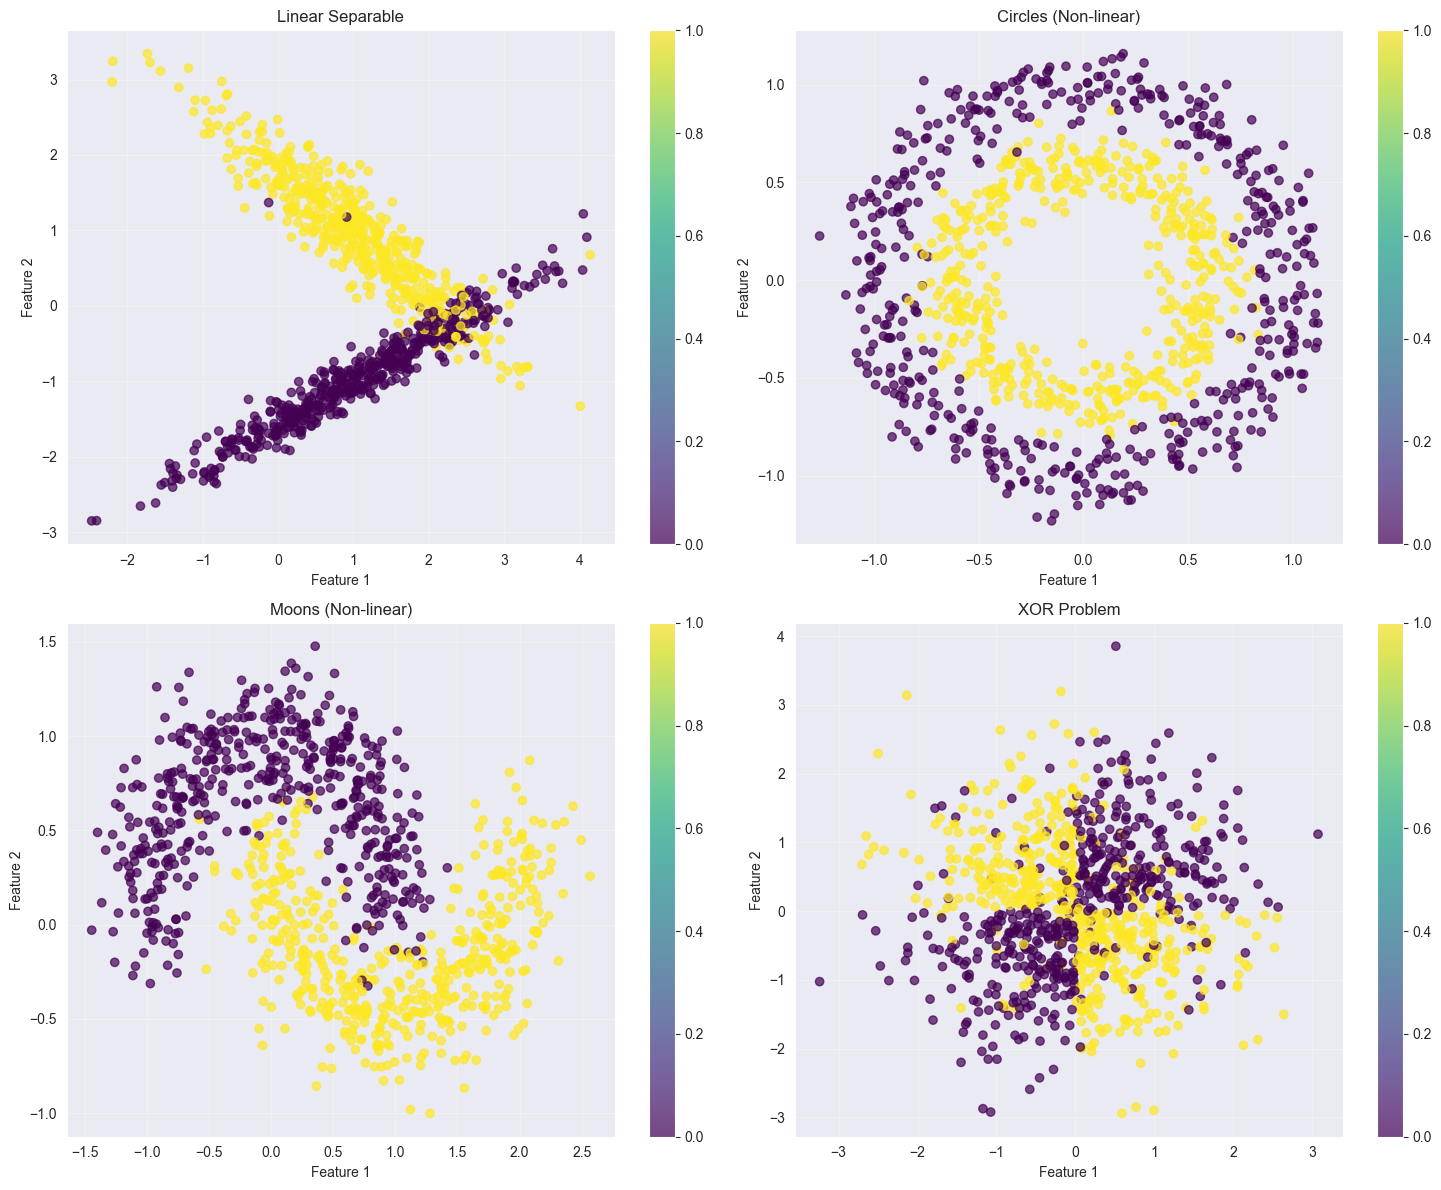

데이터셋 정보:
Linear Separable: (1000, 2), 클래스 분포: [501 499]
Circles (Non-linear): (1000, 2), 클래스 분포: [500 500]
Moons (Non-linear): (1000, 2), 클래스 분포: [500 500]
XOR Problem: (1000, 2), 클래스 분포: [497 503]


In [3]:
# 다양한 복잡도의 데이터셋 생성
def create_datasets():
    """
    신경망 학습을 위한 다양한 데이터셋 생성
    """
    datasets = {}
    
    # 1. 선형 분리 가능한 데이터 (로지스틱 회귀로 해결 가능)
    X_linear, y_linear = make_classification(
        n_samples=1000, n_features=2, n_redundant=0, n_informative=2,
        n_clusters_per_class=1, random_state=42
    )
    datasets['linear'] = (X_linear, y_linear, "Linear Separable")
    
    # 2. 원형 데이터 (비선형 분리)
    X_circles, y_circles = make_circles(n_samples=1000, noise=0.1, factor=0.6, random_state=42)
    datasets['circles'] = (X_circles, y_circles, "Circles (Non-linear)")
    
    # 3. 달 모양 데이터 (비선형 분리)
    X_moons, y_moons = make_moons(n_samples=1000, noise=0.2, random_state=42)
    datasets['moons'] = (X_moons, y_moons, "Moons (Non-linear)")
    
    # 4. XOR 문제 (고전적인 비선형 문제)
    np.random.seed(42)
    n_samples = 1000
    X_xor = np.random.randn(n_samples, 2)
    y_xor = ((X_xor[:, 0] > 0) ^ (X_xor[:, 1] > 0)).astype(int)
    # 노이즈 추가
    noise_indices = np.random.choice(n_samples, size=int(0.1 * n_samples), replace=False)
    y_xor[noise_indices] = 1 - y_xor[noise_indices]
    datasets['xor'] = (X_xor, y_xor, "XOR Problem")
    
    return datasets

# 데이터셋 생성
datasets = create_datasets()

# 데이터셋 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, (key, (X, y, title)) in enumerate(datasets.items()):
    ax = axes[i]
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()

print("데이터셋 정보:")
for key, (X, y, title) in datasets.items():
    print(f"{title}: {X.shape}, 클래스 분포: {np.bincount(y)}")

## 3. 로지스틱 회귀 vs 신경망 비교

In [4]:
def compare_logistic_vs_neural(X, y, title):
    """
    로지스틱 회귀와 간단한 신경망 성능 비교
    """
    # 데이터 전처리
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    
    results = {}
    
    # 1. 로지스틱 회귀
    lr_model = LogisticRegression(random_state=42)
    lr_model.fit(X_train, y_train)
    lr_pred = lr_model.predict(X_test)
    lr_accuracy = accuracy_score(y_test, lr_pred)
    results['Logistic Regression'] = lr_accuracy
    
    if TENSORFLOW_AVAILABLE:
        # 2. 단일층 신경망 (로지스틱 회귀와 유사)
        single_layer = models.Sequential([
            layers.Dense(1, activation='sigmoid', input_shape=(2,))
        ])
        single_layer.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        
        history_single = single_layer.fit(
            X_train, y_train,
            epochs=100,
            batch_size=32,
            validation_data=(X_test, y_test),
            verbose=0
        )
        
        single_accuracy = single_layer.evaluate(X_test, y_test, verbose=0)[1]
        results['Single Layer Neural Network'] = single_accuracy
        
        # 3. 다층 신경망
        multi_layer = models.Sequential([
            layers.Dense(16, activation='relu', input_shape=(2,)),
            layers.Dense(8, activation='relu'),
            layers.Dense(1, activation='sigmoid')
        ])
        multi_layer.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        
        history_multi = multi_layer.fit(
            X_train, y_train,
            epochs=100,
            batch_size=32,
            validation_data=(X_test, y_test),
            verbose=0
        )
        
        multi_accuracy = multi_layer.evaluate(X_test, y_test, verbose=0)[1]
        results['Multi-Layer Neural Network'] = multi_accuracy
        
        # 결정 경계 시각화
        plt.figure(figsize=(15, 5))
        
        models_to_plot = [
            (lr_model, 'Logistic Regression'),
            (single_layer, 'Single Layer NN'),
            (multi_layer, 'Multi-Layer NN')
        ]
        
        for i, (model, name) in enumerate(models_to_plot):
            plt.subplot(1, 3, i+1)
            plot_decision_boundary(model, X_scaled, y, title=f"{name}\nAccuracy: {results.get(name, results.get(name.replace(' NN', ' Neural Network'), 0)):.3f}")
        
        plt.suptitle(f"Decision Boundaries - {title}")
        plt.tight_layout()
        plt.show()
        
        # 학습 곡선 시각화
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        plt.plot(history_single.history['accuracy'], label='Single Layer - Train')
        plt.plot(history_single.history['val_accuracy'], label='Single Layer - Val')
        plt.plot(history_multi.history['accuracy'], label='Multi Layer - Train')
        plt.plot(history_multi.history['val_accuracy'], label='Multi Layer - Val')
        plt.title('Training Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        plt.plot(history_single.history['loss'], label='Single Layer - Train')
        plt.plot(history_single.history['val_loss'], label='Single Layer - Val')
        plt.plot(history_multi.history['loss'], label='Multi Layer - Train')
        plt.plot(history_multi.history['val_loss'], label='Multi Layer - Val')
        plt.title('Training Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    # 결과 출력
    print(f"\n=== {title} 결과 ===")
    for model_name, accuracy in results.items():
        print(f"{model_name:30}: {accuracy:.4f}")
    
    return results

def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    """
    결정 경계 시각화 함수
    """
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
    
    # 예측
    if hasattr(model, 'predict_proba'):  # sklearn 모델
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    else:  # Keras 모델
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0).flatten()
    
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, levels=50, alpha=0.8, cmap='RdBu')
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='black')
    plt.colorbar()
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

# 각 데이터셋에 대해 비교 실행
all_results = {}
for key, (X, y, title) in datasets.items():
    results = compare_logistic_vs_neural(X, y, title)
    all_results[key] = results


=== Linear Separable 결과 ===
Logistic Regression           : 0.9000

=== Circles (Non-linear) 결과 ===
Logistic Regression           : 0.4900

=== Moons (Non-linear) 결과 ===
Logistic Regression           : 0.9200

=== XOR Problem 결과 ===
Logistic Regression           : 0.5500


## 4. 활성화 함수 비교 실험

In [5]:
if TENSORFLOW_AVAILABLE:
    # 활성화 함수별 성능 비교
    def compare_activation_functions(X, y, title):
        """
        다양한 활성화 함수 성능 비교
        """
        # 데이터 전처리
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42, stratify=y
        )
        
        activation_functions = ['relu', 'tanh', 'sigmoid', 'elu']
        results = {}
        histories = {}
        
        for activation in activation_functions:
            print(f"Training with {activation} activation...")
            
            model = models.Sequential([
                layers.Dense(16, activation=activation, input_shape=(2,)),
                layers.Dense(8, activation=activation),
                layers.Dense(1, activation='sigmoid')
            ])
            
            model.compile(
                optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy']
            )
            
            history = model.fit(
                X_train, y_train,
                epochs=100,
                batch_size=32,
                validation_data=(X_test, y_test),
                verbose=0
            )
            
            test_accuracy = model.evaluate(X_test, y_test, verbose=0)[1]
            results[activation] = test_accuracy
            histories[activation] = history
        
        # 결과 시각화
        plt.figure(figsize=(15, 10))
        
        # 성능 비교 막대 그래프
        plt.subplot(2, 2, 1)
        activations = list(results.keys())
        accuracies = list(results.values())
        bars = plt.bar(activations, accuracies, color=['skyblue', 'lightgreen', 'orange', 'pink'])
        plt.title(f'Activation Function Performance - {title}')
        plt.ylabel('Test Accuracy')
        plt.ylim(0, 1)
        
        # 막대 위에 정확도 값 표시
        for bar, acc in zip(bars, accuracies):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{acc:.3f}', ha='center', va='bottom')
        
        # 학습 곡선 - 정확도
        plt.subplot(2, 2, 2)
        for activation, history in histories.items():
            plt.plot(history.history['val_accuracy'], label=f'{activation}')
        plt.title('Validation Accuracy During Training')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 학습 곡선 - 손실
        plt.subplot(2, 2, 3)
        for activation, history in histories.items():
            plt.plot(history.history['val_loss'], label=f'{activation}')
        plt.title('Validation Loss During Training')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 활성화 함수 모양 비교
        plt.subplot(2, 2, 4)
        x = np.linspace(-3, 3, 100)
        
        # 각 활성화 함수의 그래프
        relu_y = np.maximum(0, x)
        tanh_y = np.tanh(x)
        sigmoid_y = 1 / (1 + np.exp(-x))
        elu_y = np.where(x > 0, x, np.exp(x) - 1)
        
        plt.plot(x, relu_y, label='ReLU', linewidth=2)
        plt.plot(x, tanh_y, label='Tanh', linewidth=2)
        plt.plot(x, sigmoid_y, label='Sigmoid', linewidth=2)
        plt.plot(x, elu_y, label='ELU', linewidth=2)
        
        plt.title('Activation Function Shapes')
        plt.xlabel('Input')
        plt.ylabel('Output')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return results
    
    # 원형 데이터에 대해 활성화 함수 비교
    X_circles, y_circles, title = datasets['circles']
    activation_results = compare_activation_functions(X_circles, y_circles, "Circles Dataset")
    
    print("\n=== 활성화 함수별 성능 ===")
    for activation, accuracy in activation_results.items():
        print(f"{activation:10}: {accuracy:.4f}")
else:
    print("TensorFlow를 사용할 수 없어 활성화 함수 비교를 건너뜁니다.")

TensorFlow를 사용할 수 없어 활성화 함수 비교를 건너뜁니다.


## 5. 신경망 아키텍처 실험

In [6]:
if TENSORFLOW_AVAILABLE:
    def compare_architectures(X, y, title):
        """
        다양한 신경망 아키텍처 비교
        """
        # 데이터 전처리
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42, stratify=y
        )
        
        # 다양한 아키텍처 정의
        architectures = {
            'Shallow (2-4-1)': [2, 4, 1],
            'Medium (2-8-4-1)': [2, 8, 4, 1],
            'Deep (2-16-8-4-1)': [2, 16, 8, 4, 1],
            'Wide (2-32-1)': [2, 32, 1],
            'Very Deep (2-8-8-8-8-1)': [2, 8, 8, 8, 8, 1]
        }
        
        results = {}
        histories = {}
        models_dict = {}
        
        for arch_name, layers_config in architectures.items():
            print(f"Training {arch_name}...")
            
            # 모델 구성
            model = models.Sequential()
            
            # 첫 번째 은닉층
            model.add(layers.Dense(layers_config[1], activation='relu', input_shape=(2,)))
            
            # 중간 은닉층들
            for i in range(2, len(layers_config)-1):
                model.add(layers.Dense(layers_config[i], activation='relu'))
                # 깊은 네트워크에는 드롭아웃 추가
                if len(layers_config) > 4:
                    model.add(layers.Dropout(0.3))
            
            # 출력층
            model.add(layers.Dense(1, activation='sigmoid'))
            
            # 컴파일
            model.compile(
                optimizer=optimizers.Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy']
            )
            
            # 조기 종료 콜백
            early_stopping = callbacks.EarlyStopping(
                monitor='val_loss',
                patience=20,
                restore_best_weights=True
            )
            
            # 훈련
            history = model.fit(
                X_train, y_train,
                epochs=200,
                batch_size=32,
                validation_data=(X_test, y_test),
                callbacks=[early_stopping],
                verbose=0
            )
            
            test_accuracy = model.evaluate(X_test, y_test, verbose=0)[1]
            results[arch_name] = test_accuracy
            histories[arch_name] = history
            models_dict[arch_name] = model
        
        # 결과 시각화
        plt.figure(figsize=(15, 12))
        
        # 성능 비교
        plt.subplot(2, 3, 1)
        arch_names = list(results.keys())
        accuracies = list(results.values())
        bars = plt.bar(range(len(arch_names)), accuracies)
        plt.title(f'Architecture Performance - {title}')
        plt.ylabel('Test Accuracy')
        plt.xticks(range(len(arch_names)), arch_names, rotation=45)
        plt.ylim(0, 1)
        
        for bar, acc in zip(bars, accuracies):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{acc:.3f}', ha='center', va='bottom')
        
        # 학습 곡선 - 정확도
        plt.subplot(2, 3, 2)
        for arch_name, history in histories.items():
            plt.plot(history.history['val_accuracy'], label=arch_name, alpha=0.7)
        plt.title('Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        
        # 학습 곡선 - 손실
        plt.subplot(2, 3, 3)
        for arch_name, history in histories.items():
            plt.plot(history.history['val_loss'], label=arch_name, alpha=0.7)
        plt.title('Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        
        # 파라미터 수 비교
        plt.subplot(2, 3, 4)
        param_counts = [model.count_params() for model in models_dict.values()]
        bars = plt.bar(range(len(arch_names)), param_counts)
        plt.title('Number of Parameters')
        plt.ylabel('Parameters')
        plt.xticks(range(len(arch_names)), arch_names, rotation=45)
        
        for bar, count in zip(bars, param_counts):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(param_counts)*0.01,
                    f'{count}', ha='center', va='bottom')
        
        # 훈련 시간 vs 성능
        plt.subplot(2, 3, 5)
        training_epochs = [len(history.history['loss']) for history in histories.values()]
        plt.scatter(training_epochs, accuracies, s=100)
        for i, arch_name in enumerate(arch_names):
            plt.annotate(arch_name.split()[0], 
                        (training_epochs[i], accuracies[i]),
                        xytext=(5, 5), textcoords='offset points')
        plt.xlabel('Training Epochs')
        plt.ylabel('Test Accuracy')
        plt.title('Training Efficiency')
        plt.grid(True, alpha=0.3)
        
        # 최고 성능 모델의 결정 경계
        plt.subplot(2, 3, 6)
        best_arch = max(results.keys(), key=lambda x: results[x])
        best_model = models_dict[best_arch]
        plot_decision_boundary(best_model, X_scaled, y, 
                             title=f"Best Model: {best_arch}\nAccuracy: {results[best_arch]:.3f}")
        
        plt.tight_layout()
        plt.show()
        
        return results, models_dict
    
    # XOR 문제에 대해 아키텍처 비교
    X_xor, y_xor, title = datasets['xor']
    arch_results, arch_models = compare_architectures(X_xor, y_xor, "XOR Problem")
    
    print("\n=== 아키텍처별 성능 (XOR 문제) ===")
    for arch_name, accuracy in arch_results.items():
        param_count = arch_models[arch_name].count_params()
        print(f"{arch_name:20}: {accuracy:.4f} (파라미터: {param_count})")
else:
    print("TensorFlow를 사용할 수 없어 아키텍처 비교를 건너뜁니다.")

TensorFlow를 사용할 수 없어 아키텍처 비교를 건너뜁니다.


## 6. 최적화 알고리즘 비교

In [7]:
if TENSORFLOW_AVAILABLE:
    def compare_optimizers(X, y, title):
        """
        다양한 최적화 알고리즘 비교
        """
        # 데이터 전처리
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42, stratify=y
        )
        
        # 다양한 최적화 알고리즘
        optimizers_list = {
            'SGD': optimizers.SGD(learning_rate=0.01),
            'SGD + Momentum': optimizers.SGD(learning_rate=0.01, momentum=0.9),
            'RMSprop': optimizers.RMSprop(learning_rate=0.001),
            'Adam': optimizers.Adam(learning_rate=0.001),
            'AdaGrad': optimizers.Adagrad(learning_rate=0.01)
        }
        
        results = {}
        histories = {}
        
        for opt_name, optimizer in optimizers_list.items():
            print(f"Training with {opt_name}...")
            
            # 동일한 아키텍처 사용
            model = models.Sequential([
                layers.Dense(16, activation='relu', input_shape=(2,)),
                layers.Dense(8, activation='relu'),
                layers.Dense(1, activation='sigmoid')
            ])
            
            model.compile(
                optimizer=optimizer,
                loss='binary_crossentropy',
                metrics=['accuracy']
            )
            
            history = model.fit(
                X_train, y_train,
                epochs=100,
                batch_size=32,
                validation_data=(X_test, y_test),
                verbose=0
            )
            
            test_accuracy = model.evaluate(X_test, y_test, verbose=0)[1]
            results[opt_name] = test_accuracy
            histories[opt_name] = history
        
        # 결과 시각화
        plt.figure(figsize=(15, 10))
        
        # 최적화 알고리즘별 성능
        plt.subplot(2, 3, 1)
        opt_names = list(results.keys())
        accuracies = list(results.values())
        bars = plt.bar(opt_names, accuracies)
        plt.title(f'Optimizer Performance - {title}')
        plt.ylabel('Test Accuracy')
        plt.xticks(rotation=45)
        plt.ylim(0, 1)
        
        for bar, acc in zip(bars, accuracies):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{acc:.3f}', ha='center', va='bottom')
        
        # 학습 곡선 - 정확도
        plt.subplot(2, 3, 2)
        for opt_name, history in histories.items():
            plt.plot(history.history['accuracy'], label=f'{opt_name} (train)', alpha=0.7)
            plt.plot(history.history['val_accuracy'], label=f'{opt_name} (val)', linestyle='--', alpha=0.7)
        plt.title('Training Progress - Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        
        # 학습 곡선 - 손실 (로그 스케일)
        plt.subplot(2, 3, 3)
        for opt_name, history in histories.items():
            plt.plot(history.history['loss'], label=f'{opt_name} (train)', alpha=0.7)
            plt.plot(history.history['val_loss'], label=f'{opt_name} (val)', linestyle='--', alpha=0.7)
        plt.title('Training Progress - Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.yscale('log')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        
        # 수렴 속도 분석
        plt.subplot(2, 3, 4)
        convergence_epochs = []
        final_accuracies = []
        
        for opt_name, history in histories.items():
            val_acc = history.history['val_accuracy']
            # 90% 최종 성능에 도달하는 에포크 찾기
            target_acc = max(val_acc) * 0.9
            convergence_epoch = next((i for i, acc in enumerate(val_acc) if acc >= target_acc), len(val_acc))
            convergence_epochs.append(convergence_epoch)
            final_accuracies.append(max(val_acc))
        
        plt.scatter(convergence_epochs, final_accuracies, s=100)
        for i, opt_name in enumerate(opt_names):
            plt.annotate(opt_name, (convergence_epochs[i], final_accuracies[i]),
                        xytext=(5, 5), textcoords='offset points')
        plt.xlabel('Epochs to 90% Performance')
        plt.ylabel('Final Accuracy')
        plt.title('Convergence Speed vs Final Performance')
        plt.grid(True, alpha=0.3)
        
        # 손실 감소 패턴
        plt.subplot(2, 3, 5)
        for opt_name, history in histories.items():
            loss_reduction = np.array(history.history['val_loss'])
            # 첫 10 에포크 동안의 손실 감소율
            if len(loss_reduction) >= 10:
                reduction_rate = (loss_reduction[0] - loss_reduction[9]) / loss_reduction[0]
                plt.bar(opt_name, reduction_rate)
        
        plt.title('Loss Reduction Rate (First 10 Epochs)')
        plt.ylabel('Reduction Rate')
        plt.xticks(rotation=45)
        
        # 최적화 알고리즘별 특성 설명
        plt.subplot(2, 3, 6)
        plt.axis('off')
        
        explanation_text = """
        최적화 알고리즘 특성:
        
        • SGD: 가장 기본적인 방법
        • SGD + Momentum: 관성을 이용해 진동 감소
        • RMSprop: 적응적 학습률 조정
        • Adam: Momentum + RMSprop 결합
        • AdaGrad: 누적 그래디언트로 학습률 조정
        
        일반적으로 Adam이 좋은 시작점이지만,
        문제에 따라 다른 최적화 알고리즘이
        더 좋을 수 있습니다.
        """
        
        plt.text(0.1, 0.9, explanation_text, transform=plt.gca().transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.5))
        
        plt.tight_layout()
        plt.show()
        
        return results
    
    # 달 모양 데이터에 대해 최적화 알고리즘 비교
    X_moons, y_moons, title = datasets['moons']
    optimizer_results = compare_optimizers(X_moons, y_moons, "Moons Dataset")
    
    print("\n=== 최적화 알고리즘별 성능 ===")
    for opt_name, accuracy in optimizer_results.items():
        print(f"{opt_name:15}: {accuracy:.4f}")
else:
    print("TensorFlow를 사용할 수 없어 최적화 알고리즘 비교를 건너뜁니다.")

TensorFlow를 사용할 수 없어 최적화 알고리즘 비교를 건너뜁니다.


## 7. 과적합 방지 기법

In [8]:
if TENSORFLOW_AVAILABLE:
    def compare_regularization_techniques(X, y, title):
        """
        과적합 방지 기법들 비교
        """
        # 의도적으로 작은 데이터셋 사용 (과적합 유도)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # 작은 훈련 세트 사용
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.5, random_state=42, stratify=y
        )
        
        # 다양한 정규화 기법
        regularization_methods = {
            'No Regularization': lambda: models.Sequential([
                layers.Dense(64, activation='relu', input_shape=(2,)),
                layers.Dense(32, activation='relu'),
                layers.Dense(16, activation='relu'),
                layers.Dense(1, activation='sigmoid')
            ]),
            
            'Dropout': lambda: models.Sequential([
                layers.Dense(64, activation='relu', input_shape=(2,)),
                layers.Dropout(0.5),
                layers.Dense(32, activation='relu'),
                layers.Dropout(0.3),
                layers.Dense(16, activation='relu'),
                layers.Dropout(0.2),
                layers.Dense(1, activation='sigmoid')
            ]),
            
            'L1 Regularization': lambda: models.Sequential([
                layers.Dense(64, activation='relu', input_shape=(2,),
                           kernel_regularizer=keras.regularizers.l1(0.01)),
                layers.Dense(32, activation='relu',
                           kernel_regularizer=keras.regularizers.l1(0.01)),
                layers.Dense(16, activation='relu',
                           kernel_regularizer=keras.regularizers.l1(0.01)),
                layers.Dense(1, activation='sigmoid')
            ]),
            
            'L2 Regularization': lambda: models.Sequential([
                layers.Dense(64, activation='relu', input_shape=(2,),
                           kernel_regularizer=keras.regularizers.l2(0.01)),
                layers.Dense(32, activation='relu',
                           kernel_regularizer=keras.regularizers.l2(0.01)),
                layers.Dense(16, activation='relu',
                           kernel_regularizer=keras.regularizers.l2(0.01)),
                layers.Dense(1, activation='sigmoid')
            ]),
            
            'Early Stopping': lambda: models.Sequential([
                layers.Dense(64, activation='relu', input_shape=(2,)),
                layers.Dense(32, activation='relu'),
                layers.Dense(16, activation='relu'),
                layers.Dense(1, activation='sigmoid')
            ])
        }
        
        results = {}
        histories = {}
        
        for method_name, model_func in regularization_methods.items():
            print(f"Training with {method_name}...")
            
            model = model_func()
            model.compile(
                optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy']
            )
            
            # 콜백 설정
            callbacks_list = []
            if method_name == 'Early Stopping':
                callbacks_list.append(
                    callbacks.EarlyStopping(
                        monitor='val_loss',
                        patience=15,
                        restore_best_weights=True
                    )
                )
            
            history = model.fit(
                X_train, y_train,
                epochs=200,
                batch_size=16,
                validation_data=(X_test, y_test),
                callbacks=callbacks_list,
                verbose=0
            )
            
            # 평가
            train_accuracy = model.evaluate(X_train, y_train, verbose=0)[1]
            test_accuracy = model.evaluate(X_test, y_test, verbose=0)[1]
            
            results[method_name] = {
                'train_acc': train_accuracy,
                'test_acc': test_accuracy,
                'overfitting': train_accuracy - test_accuracy
            }
            histories[method_name] = history
        
        # 결과 시각화
        plt.figure(figsize=(15, 12))
        
        # 과적합 정도 비교
        plt.subplot(2, 3, 1)
        methods = list(results.keys())
        train_accs = [results[m]['train_acc'] for m in methods]
        test_accs = [results[m]['test_acc'] for m in methods]
        
        x = np.arange(len(methods))
        width = 0.35
        
        plt.bar(x - width/2, train_accs, width, label='Train Accuracy', alpha=0.8)
        plt.bar(x + width/2, test_accs, width, label='Test Accuracy', alpha=0.8)
        plt.xlabel('Regularization Method')
        plt.ylabel('Accuracy')
        plt.title(f'Overfitting Comparison - {title}')
        plt.xticks(x, methods, rotation=45)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 과적합 정도 (훈련 - 테스트 정확도 차이)
        plt.subplot(2, 3, 2)
        overfitting_scores = [results[m]['overfitting'] for m in methods]
        bars = plt.bar(methods, overfitting_scores, color='red', alpha=0.7)
        plt.ylabel('Overfitting Score (Train - Test)')
        plt.title('Overfitting Degree')
        plt.xticks(rotation=45)
        plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        
        for bar, score in zip(bars, overfitting_scores):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{score:.3f}', ha='center', va='bottom')
        
        # 학습 곡선 - 정확도
        plt.subplot(2, 3, 3)
        for method_name, history in histories.items():
            plt.plot(history.history['accuracy'], label=f'{method_name} (train)', alpha=0.7)
            plt.plot(history.history['val_accuracy'], label=f'{method_name} (val)', 
                    linestyle='--', alpha=0.7)
        plt.title('Training Curves - Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        
        # 학습 곡선 - 손실
        plt.subplot(2, 3, 4)
        for method_name, history in histories.items():
            plt.plot(history.history['loss'], label=f'{method_name} (train)', alpha=0.7)
            plt.plot(history.history['val_loss'], label=f'{method_name} (val)', 
                    linestyle='--', alpha=0.7)
        plt.title('Training Curves - Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        
        # 정규화 효과 분석
        plt.subplot(2, 3, 5)
        test_accs_only = [results[m]['test_acc'] for m in methods]
        overfitting_only = [results[m]['overfitting'] for m in methods]
        
        plt.scatter(overfitting_only, test_accs_only, s=100)
        for i, method in enumerate(methods):
            plt.annotate(method.split()[0], 
                        (overfitting_only[i], test_accs_only[i]),
                        xytext=(5, 5), textcoords='offset points')
        
        plt.xlabel('Overfitting Score')
        plt.ylabel('Test Accuracy')
        plt.title('Regularization Effectiveness')
        plt.grid(True, alpha=0.3)
        
        # 정규화 기법 설명
        plt.subplot(2, 3, 6)
        plt.axis('off')
        
        explanation_text = """
        정규화 기법들:
        
        • Dropout: 훈련 중 일부 뉴런을 무작위로 제거
        • L1 정규화: 가중치의 절댓값 합에 페널티
        • L2 정규화: 가중치의 제곱합에 페널티
        • Early Stopping: 검증 손실이 증가하면 조기 종료
        
        목표: 훈련과 테스트 성능 차이 최소화
        
        일반적으로 Dropout + Early Stopping
        조합이 효과적입니다.
        """
        
        plt.text(0.1, 0.9, explanation_text, transform=plt.gca().transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.5))
        
        plt.tight_layout()
        plt.show()
        
        return results
    
    # 선형 분리 가능한 데이터에 대해 정규화 기법 비교
    X_linear, y_linear, title = datasets['linear']
    regularization_results = compare_regularization_techniques(X_linear, y_linear, "Linear Dataset")
    
    print("\n=== 정규화 기법별 결과 ===")
    print(f"{'Method':<20} {'Train Acc':<10} {'Test Acc':<10} {'Overfitting':<12}")
    print("-" * 55)
    for method, metrics in regularization_results.items():
        print(f"{method:<20} {metrics['train_acc']:<10.4f} {metrics['test_acc']:<10.4f} {metrics['overfitting']:<12.4f}")
else:
    print("TensorFlow를 사용할 수 없어 정규화 기법 비교를 건너뜁니다.")

TensorFlow를 사용할 수 없어 정규화 기법 비교를 건너뜁니다.


## 8. 신경망 시각화 및 해석

In [9]:
if TENSORFLOW_AVAILABLE:
    def visualize_neural_network():
        """
        신경망 구조와 학습 과정 시각화
        """
        # 간단한 신경망 생성
        model = models.Sequential([
            layers.Dense(8, activation='relu', input_shape=(2,), name='hidden_layer_1'),
            layers.Dense(4, activation='relu', name='hidden_layer_2'),
            layers.Dense(1, activation='sigmoid', name='output_layer')
        ])
        
        model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        
        # 모델 구조 출력
        print("=== 신경망 구조 ===")
        model.summary()
        
        # 원형 데이터로 훈련
        X_circles, y_circles, _ = datasets['circles']
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_circles)
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y_circles, test_size=0.2, random_state=42, stratify=y_circles
        )
        
        # 가중치 변화 추적을 위한 콜백
        class WeightTracker(callbacks.Callback):
            def __init__(self):
                self.weights_history = []
                
            def on_epoch_end(self, epoch, logs=None):
                if epoch % 10 == 0:  # 10 에포크마다 저장
                    weights = []
                    for layer in self.model.layers:
                        if layer.get_weights():  # 가중치가 있는 층만
                            weights.append(layer.get_weights()[0].copy())
                    self.weights_history.append(weights)
        
        weight_tracker = WeightTracker()
        
        # 모델 훈련
        history = model.fit(
            X_train, y_train,
            epochs=100,
            batch_size=32,
            validation_data=(X_test, y_test),
            callbacks=[weight_tracker],
            verbose=0
        )
        
        # 시각화
        plt.figure(figsize=(15, 12))
        
        # 1. 신경망 아키텍처 다이어그램 (텍스트 기반)
        plt.subplot(2, 3, 1)
        plt.axis('off')
        
        # 간단한 네트워크 구조 그리기
        layer_sizes = [2, 8, 4, 1]
        layer_names = ['Input\n(2)', 'Hidden 1\n(8)', 'Hidden 2\n(4)', 'Output\n(1)']
        
        max_neurons = max(layer_sizes)
        for i, (size, name) in enumerate(zip(layer_sizes, layer_names)):
            x = i * 2
            y_positions = np.linspace(-max_neurons/2, max_neurons/2, size)
            
            # 뉴런 그리기
            for y in y_positions:
                circle = plt.Circle((x, y), 0.3, color='lightblue', ec='black')
                plt.gca().add_patch(circle)
            
            # 레이어 이름
            plt.text(x, max_neurons/2 + 1, name, ha='center', va='bottom', fontweight='bold')
            
            # 연결선 그리기
            if i < len(layer_sizes) - 1:
                next_y_positions = np.linspace(-max_neurons/2, max_neurons/2, layer_sizes[i+1])
                for y1 in y_positions:
                    for y2 in next_y_positions:
                        plt.plot([x + 0.3, x + 2 - 0.3], [y1, y2], 'k-', alpha=0.3, linewidth=0.5)
        
        plt.xlim(-1, (len(layer_sizes)-1) * 2 + 1)
        plt.ylim(-max_neurons/2 - 2, max_neurons/2 + 2)
        plt.title('Neural Network Architecture')
        
        # 2. 가중치 분포 변화
        plt.subplot(2, 3, 2)
        if weight_tracker.weights_history:
            # 첫 번째 층의 가중치 분포 변화
            initial_weights = weight_tracker.weights_history[0][0].flatten()
            final_weights = weight_tracker.weights_history[-1][0].flatten()
            
            plt.hist(initial_weights, bins=20, alpha=0.7, label='Initial', color='red')
            plt.hist(final_weights, bins=20, alpha=0.7, label='Final', color='blue')
            plt.xlabel('Weight Value')
            plt.ylabel('Frequency')
            plt.title('Weight Distribution Change\n(First Layer)')
            plt.legend()
        
        # 3. 학습 과정
        plt.subplot(2, 3, 3)
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Process')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 4. 중간층 활성화 시각화
        plt.subplot(2, 3, 4)
        
        # 중간층 출력을 위한 모델 생성
        intermediate_model = models.Model(
            inputs=model.input,
            outputs=model.get_layer('hidden_layer_1').output
        )
        
        # 몇 개 샘플에 대한 중간층 활성화
        sample_inputs = X_test[:5]
        activations = intermediate_model.predict(sample_inputs, verbose=0)
        
        # 히트맵으로 표시
        plt.imshow(activations.T, cmap='viridis', aspect='auto')
        plt.colorbar()
        plt.xlabel('Sample')
        plt.ylabel('Neuron')
        plt.title('Hidden Layer 1 Activations')
        
        # 5. 결정 경계 진화
        plt.subplot(2, 3, 5)
        plot_decision_boundary(model, X_scaled, y_circles, 
                             title=f"Final Decision Boundary\nAccuracy: {model.evaluate(X_test, y_test, verbose=0)[1]:.3f}")
        
        # 6. 예측 확률 분포
        plt.subplot(2, 3, 6)
        y_proba = model.predict(X_test, verbose=0).flatten()
        
        plt.hist(y_proba[y_test == 0], bins=20, alpha=0.7, label='Class 0', color='red')
        plt.hist(y_proba[y_test == 1], bins=20, alpha=0.7, label='Class 1', color='blue')
        plt.axvline(x=0.5, color='black', linestyle='--', label='Decision Threshold')
        plt.xlabel('Predicted Probability')
        plt.ylabel('Frequency')
        plt.title('Prediction Probability Distribution')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        return model, history
    
    # 신경망 시각화 실행
    visualization_model, visualization_history = visualize_neural_network()
else:
    print("TensorFlow를 사용할 수 없어 신경망 시각화를 건너뜁니다.")

TensorFlow를 사용할 수 없어 신경망 시각화를 건너뜁니다.


## 9. 실습 정리 및 핵심 개념

In [10]:
# 전체 실험 결과 요약
print("=" * 80)
print("                  신경망 기초 실습 결과 요약")
print("=" * 80)

print("\n1. 데이터 복잡도별 성능 비교:")
print("-" * 50)
if 'all_results' in locals():
    for dataset_name, results in all_results.items():
        dataset_title = datasets[dataset_name][2]
        print(f"\n{dataset_title}:")
        for model_name, accuracy in results.items():
            print(f"  {model_name:30}: {accuracy:.4f}")

print("\n\n2. 주요 학습 내용:")
print("-" * 50)

key_learnings = [
    "• 로지스틱 회귀는 선형 분리 가능한 문제에서 신경망과 유사한 성능",
    "• 비선형 문제(XOR, 원형, 달 모양)에서는 다층 신경망이 필수",
    "• ReLU는 대부분의 경우에서 좋은 성능을 보이는 활성화 함수",
    "• Adam 최적화는 일반적으로 안정적이고 빠른 수렴을 제공",
    "• 과적합 방지를 위해 Dropout과 Early Stopping이 효과적",
    "• 네트워크가 깊어질수록 더 복잡한 패턴을 학습할 수 있음",
    "• 적절한 정규화 없이는 복잡한 모델이 오히려 성능을 저하시킬 수 있음"
]

for learning in key_learnings:
    print(learning)

print("\n\n3. 실무 적용 가이드라인:")
print("-" * 50)

guidelines = [
    "• 간단한 문제부터 시작해서 점진적으로 복잡성 증가",
    "• 기본 설정: ReLU 활성화 + Adam 최적화 + Dropout",
    "• 과적합 확인: 훈련과 검증 성능 차이 모니터링",
    "• 하이퍼파라미터 튜닝: 학습률, 배치 크기, 네트워크 구조",
    "• 조기 종료로 최적 지점에서 훈련 중단",
    "• 결정 경계 시각화로 모델 동작 이해"
]

for guideline in guidelines:
    print(guideline)

print("\n\n4. 다음 단계 학습 주제:")
print("-" * 50)

next_topics = [
    "• 합성곱 신경망 (CNN) - 이미지 처리",
    "• 순환 신경망 (RNN/LSTM) - 시계열/텍스트 처리",
    "• 전이 학습 (Transfer Learning)",
    "• 생성 모델 (GAN, VAE)",
    "• 강화 학습 기초",
    "• 모델 해석 및 시각화 고급 기법"
]

for topic in next_topics:
    print(topic)

print("\n\n5. 환경별 실행 참고사항:")
print("-" * 50)

if IN_COLAB:
    print("✓ Google Colab 환경에서 실행됨")
    print("• GPU 사용을 위해 런타임 > 런타임 유형 변경 > GPU 선택")
    print("• 대용량 데이터셋 사용 시 Google Drive 마운트 고려")
else:
    print("✓ 로컬 환경에서 실행됨")
    if TENSORFLOW_AVAILABLE:
        print("• TensorFlow 사용 가능")
        if tf.config.list_physical_devices('GPU'):
            print("• GPU 사용 가능")
        else:
            print("• CPU 모드로 실행 중 (GPU 가속을 위해 CUDA 설치 고려)")
    else:
        print("• TensorFlow 설치 필요: pip install tensorflow")

print("\n" + "=" * 80)
print("                        실습 완료!")
print("=" * 80)

                  신경망 기초 실습 결과 요약

1. 데이터 복잡도별 성능 비교:
--------------------------------------------------

Linear Separable:
  Logistic Regression           : 0.9000

Circles (Non-linear):
  Logistic Regression           : 0.4900

Moons (Non-linear):
  Logistic Regression           : 0.9200

XOR Problem:
  Logistic Regression           : 0.5500


2. 주요 학습 내용:
--------------------------------------------------
• 로지스틱 회귀는 선형 분리 가능한 문제에서 신경망과 유사한 성능
• 비선형 문제(XOR, 원형, 달 모양)에서는 다층 신경망이 필수
• ReLU는 대부분의 경우에서 좋은 성능을 보이는 활성화 함수
• Adam 최적화는 일반적으로 안정적이고 빠른 수렴을 제공
• 과적합 방지를 위해 Dropout과 Early Stopping이 효과적
• 네트워크가 깊어질수록 더 복잡한 패턴을 학습할 수 있음
• 적절한 정규화 없이는 복잡한 모델이 오히려 성능을 저하시킬 수 있음


3. 실무 적용 가이드라인:
--------------------------------------------------
• 간단한 문제부터 시작해서 점진적으로 복잡성 증가
• 기본 설정: ReLU 활성화 + Adam 최적화 + Dropout
• 과적합 확인: 훈련과 검증 성능 차이 모니터링
• 하이퍼파라미터 튜닝: 학습률, 배치 크기, 네트워크 구조
• 조기 종료로 최적 지점에서 훈련 중단
• 결정 경계 시각화로 모델 동작 이해


4. 다음 단계 학습 주제:
--------------------------------------------------
• 합성곱 신경망 (CNN

## 10. 추가 실험 및 연습 문제

### 연습 문제 1: 나만의 활성화 함수
- Swish 활성화 함수 (x * sigmoid(x))를 구현하고 다른 활성화 함수와 비교해보세요

### 연습 문제 2: 배치 정규화 실험
- BatchNormalization 층을 추가하여 깊은 네트워크의 성능을 개선해보세요

### 연습 문제 3: 학습률 스케줄링
- 학습률을 동적으로 조정하는 스케줄러를 사용해보세요

### 연습 문제 4: 앙상블 모델
- 여러 신경망을 조합한 앙상블 모델을 만들어보세요

### 연습 문제 5: 실제 데이터셋 적용
- scikit-learn의 다른 데이터셋(wine, breast_cancer 등)에 적용해보세요